In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def parse_output(file_path, n_experiments=5):
    initial_ram = 0
    data_load_time = 0
    encoding_time = 0
    scaling_time = 0
    total_time = 0
    final_ram = 0
    with open(file_path, 'r') as fout:
        for _ in range(n_experiments):
            initial_ram += float(fout.readline().split()[-1][:-1])
            data_load_time += float(fout.readline().split()[-2])
            encoding_time += float(fout.readline().split()[-2])
            scaling_time += float(fout.readline().split()[-2])
            total_time += float(fout.readline().split()[-2])
            final_ram += float(fout.readline().split()[-1][:-1])
    
    return np.array([initial_ram, data_load_time, encoding_time, scaling_time, total_time, final_ram]) / n_experiments

In [6]:
three = parse_output('/home/alex/study/big-data-labs/lab2/three_nodes.txt')
three_opt = parse_output('/home/alex/study/big-data-labs/lab2/three_nodes_opt.txt')
one = parse_output('/home/alex/study/big-data-labs/lab2/one_node.txt')
one_opt = parse_output('/home/alex/study/big-data-labs/lab2/one_node_opt.txt')

Результаты, показанные на графиках являются усреднением по 5 запускам для каждого варианта (количество датанод, оптимизации)

Среднее время работы ключевых стадий скрипта

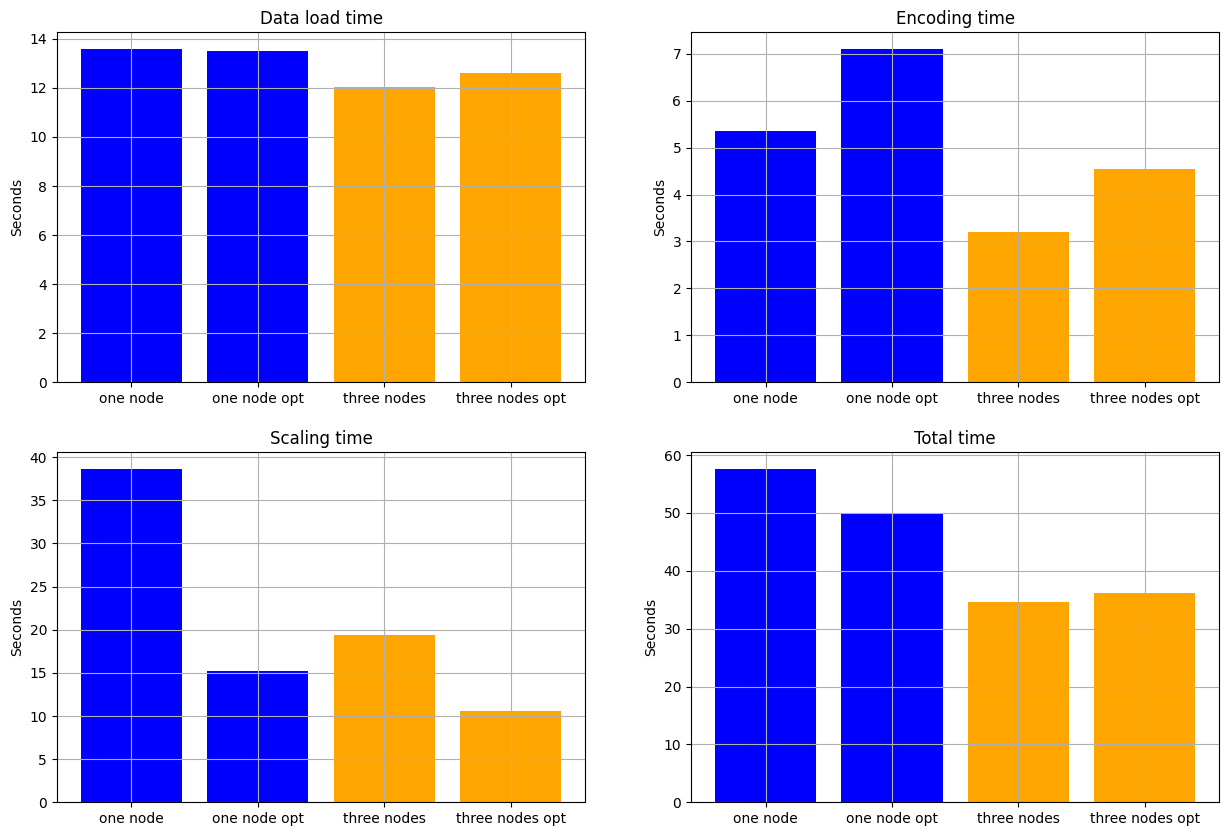

In [7]:
xticks = [0, 1, 2, 3]
xlabels = ['one node', 'one node opt', 'three nodes', 'three nodes opt']
colors = ['blue', 'blue', 'orange', 'orange']
titles = ['Data load time', 'Encoding time', 'Scaling time', 'Total time']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, (i, j) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
    axes[i][j].bar(xticks, [one[idx+1], one_opt[idx+1], three[idx+1], three_opt[idx+1]], color=colors)
    axes[i][j].set_xticks(xticks)
    axes[i][j].set_xticklabels(xlabels)
    axes[i][j].set_title(titles[idx])
    axes[i][j].set_ylabel('Seconds')
    axes[i][j].grid(True)

Использование памяти (для каждого варианта один столбик означает начальное использвание памяти, а другой - конечное)

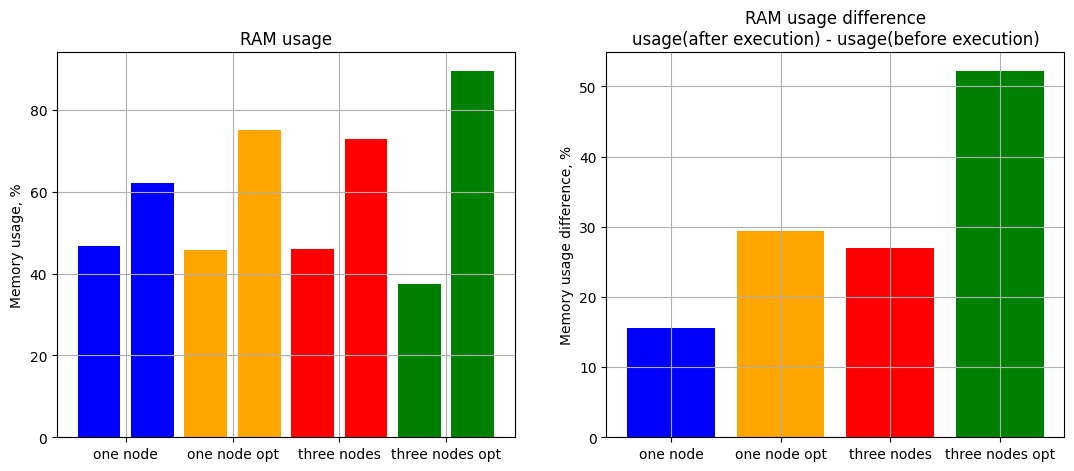

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].set_title('RAM usage')
axes[0].bar(range(0, 8), [one[0], one[-1],
                 one_opt[0], one_opt[-1],
                 three[0], three[-1],
                 three_opt[0], three_opt[-1]],
        color=[*(['blue']*2),
               *(['orange']*2),
               *(['red']*2),
               *(['green']*2)])
axes[0].set_ylabel('Memory usage, %')
axes[0].set_xticks(np.arange(0.5, 7, 2))
axes[0].set_xticklabels(['one node', 'one node opt', 'three nodes', 'three nodes opt'])
axes[0].grid(True)

axes[1].set_title('RAM usage difference\nusage(after execution) - usage(before execution)')
axes[1].bar(range(0, 4), [one[-1] - one[0],
                 one_opt[-1] - one_opt[0],
                 three[-1] - three[0],
                 three_opt[-1] - three_opt[0]],
        color=['blue', 'orange', 'red', 'green'])
axes[1].set_ylabel('Memory usage difference, %')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['one node', 'one node opt', 'three nodes', 'three nodes opt'])
axes[1].grid(True)